# Taller de Modelado de Riesgo Crediticio (HELOC)
Autor: _[Tu Nombre Aquí]_  
Fecha: _[Completar]_  

Este cuaderno contiene las instrucciones para completar tareas de regresión y clasificación sobre el dataset **Home‑Equity Line of Credit (HELOC)**. Sigue cada sección, agrega tus celdas de código donde se indique **TODO**, y responde las preguntas solicitadas.

| Aspecto | Detalle |
|---------|---------|
| **Origen** | Publicado por **FICO®** como parte de su “Explainable Machine Learning Challenge” (2018); disponible en Kaggle y en el repositorio oficial de la competencia. |
| **Observaciones** | **10 459** solicitudes de línea de crédito hipotecaria (clientes únicos). |
| **Variables** | **24 columnas** en total: 1 objetivo (`RiskPerformance`) + 23 predictoras numéricas y categóricas codificadas como enteros. |
| **Variable objetivo** | `RiskPerformance` &rarr; “Good” (0) ó “Bad” (1). “Bad” indica que el cliente incurrió en default, morosidad grave o cierre por cobranza. |
| **Variables predictoras clave** | `ExternalRiskEstimate`, `MSinceMostRecentDelq`, `NumTotalTrades`, `PercentTradesNeverDelq`, `NetFractionRevolvingBurden`, entre otras. Representan historiales de crédito, antigüedad de líneas, morosidades y utilización de cupo. |
| **Codificación de faltantes** | El valor **–8** indica “no disponible” (missing). No existen `NaN` nativos; se debe convertir –8 → `NaN` antes de imputar o escalar. |
| **Balance de clases** | ~ **74 %** “Good” vs. **26 %** “Bad” (dataset moderadamente desbalanceado). |
| **Posibles tareas** | 1) **Clasificación** del riesgo (`RiskPerformance`).<br>2) **Regresión** del score de riesgo (`ExternalRiskEstimate`) o métricas de carga financiera (`NetFraction*`). |
| **Licencia / uso** | Datos anonimizados, liberados exclusivamente con fines académicos y de investigación; no incluyen información personal identificable. |

## Codificación de Faltantes

| Value                | Meaning                                                            |
| -------------------- | ------------------------------------------------------------------ |
| `-9`                 | **No Bureau Record or No Matching Trade** (missing / not reported) |
| `-8`                 | No Usable/Valid Trades                                             |
| `-7`                 | Condition not met                                                  |
| other numeric values | Valid feature values                                               |


## 1. Carga de librerías y datos
Ejecuta la celda siguiente para cargar el CSV que ya descargaste (`heloc_dataset_v1.csv`). Si lo tienes en otra ruta, ajusta el _path_.

In [16]:
import pandas as pd
import numpy as np

# Cargar datos
df = pd.read_csv('heloc_dataset_v1.csv')

# Vista preliminar
df.head()

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


# 2. Exploración de los datos

In [17]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10459 entries, 0 to 10458
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   RiskPerformance                     10459 non-null  str  
 1   ExternalRiskEstimate                10459 non-null  int64
 2   MSinceOldestTradeOpen               10459 non-null  int64
 3   MSinceMostRecentTradeOpen           10459 non-null  int64
 4   AverageMInFile                      10459 non-null  int64
 5   NumSatisfactoryTrades               10459 non-null  int64
 6   NumTrades60Ever2DerogPubRec         10459 non-null  int64
 7   NumTrades90Ever2DerogPubRec         10459 non-null  int64
 8   PercentTradesNeverDelq              10459 non-null  int64
 9   MSinceMostRecentDelq                10459 non-null  int64
 10  MaxDelq2PublicRecLast12M            10459 non-null  int64
 11  MaxDelqEver                         10459 non-null  int64
 12  NumTotalTrades 

In [18]:
# Descripción de los datos
df.describe()

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
count,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,...,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000,10459.000000
mean,67.425758,184.205373,8.543455,73.843293,19.428052,0.042738,-0.142843,86.661536,6.762406,4.928291,...,32.166460,-0.325366,0.868152,0.812602,31.629888,39.158906,3.185008,0.976097,0.018071,62.079166
std,21.121621,109.683816,13.301745,38.782803,13.004327,2.513910,2.367397,25.999584,20.501250,3.756275,...,20.128634,6.067556,3.179304,3.143698,30.060140,42.101601,4.413173,4.060995,3.358135,27.711565
min,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,...,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,63.000000,118.000000,3.000000,52.000000,12.000000,0.000000,0.000000,87.000000,-7.000000,4.000000,...,20.000000,-7.000000,0.000000,0.000000,5.000000,-8.000000,2.000000,1.000000,0.000000,47.000000
50%,71.000000,178.000000,5.000000,74.000000,19.000000,0.000000,0.000000,96.000000,-7.000000,6.000000,...,31.000000,0.000000,1.000000,1.000000,25.000000,47.000000,3.000000,2.000000,0.000000,67.000000
75%,79.000000,249.500000,11.000000,95.000000,27.000000,1.000000,0.000000,100.000000,14.000000,7.000000,...,44.000000,1.000000,2.000000,2.000000,54.000000,79.000000,5.000000,3.000000,1.000000,82.000000
max,94.000000,803.000000,383.000000,383.000000,79.000000,19.000000,19.000000,100.000000,83.000000,9.000000,...,100.000000,24.000000,66.000000,66.000000,232.000000,471.000000,32.000000,23.000000,18.000000,100.000000


# 3. Preprocesamiento de datos

## 📖 Guía Rápida: Criterios para la Limpieza y Transformación de Datos

Antes de aplicar cualquier algoritmo, las decisiones que tomamos sobre los datos faltantes, las escalas y los valores extremos impactan directamente en el rendimiento del modelo. Aquí tienes una guía de referencia para saber cuándo usar cada técnica:

### 1. Imputación de Valores Faltantes (Nulos)


La elección de la medida de tendencia central depende de la forma de la distribución de tus datos:

* **Media (Promedio):** * **Cuándo usarla:** Cuando la variable tiene una distribución normal (simétrica) o gaussiana.
    * **Precaución:** Es extremadamente sensible a los valores atípicos (outliers). Si hay un valor extremo, el promedio se arrastrará hacia él, distorsionando la imputación.
* **Mediana:** * **Cuándo usarla:** Cuando la distribución es asimétrica (sesgada) o cuando hay presencia de valores atípicos claros. Es la medida más robusta para datos financieros (como salarios, deudas o créditos).
* **Moda:** * **Cuándo usarla:** Exclusivamente para variables categóricas (ej. estado civil, nivel educativo) o variables numéricas discretas con muy poca variabilidad (ej. número de hijos, donde la mayoría tiene 0 o 1).

---

### 2. Escalamiento de Datos
Muchos algoritmos de Machine Learning (como PCA, KNN o SVM) calculan distancias entre puntos. Si una variable está en miles (ej. ingresos) y otra en decimales (ej. tasas de interés), el modelo le dará más peso a la primera solo por su magnitud.

| Técnica | ¿Qué hace? | ¿Cuándo usarla? |
| :--- | :--- | :--- |
| **Estandarización (StandardScaler)** | Centra los datos en una media de 0 y una desviación estándar de 1 (Z-score). No acota los datos a un rango específico. | Es el estándar para algoritmos que asumen normalidad o calculan varianzas, **como el PCA**, Regresión Lineal o Regresión Logística. Es menos sensible a outliers que la normalización. |
| **Normalización (MinMaxScaler)** | Comprime todos los datos a un rango fijo, generalmente entre 0 y 1. | Útil cuando no asumimos ninguna distribución en particular, en Redes Neuronales, procesamiento de imágenes, o cuando los límites exactos (0 a 1) son importantes. **Precaución:** Muy sensible a los outliers, ya que un valor extremo aplastará al resto de los datos en un rango diminuto. |

---

### 3. El Dilema de los Valores Atípicos (Outliers)

Un *outlier* no siempre es un error; muchas veces es la información más valiosa del dataset (por ejemplo, en detección de fraudes o en la predicción de quiebras crediticias).

* **Cuándo NO imputar ni eliminar (Mantenerlos):**
    * Cuando representan eventos reales y críticos que el modelo necesita aprender (ej. clientes de muy alto riesgo en nuestro dataset HELOC).
    * Cuando vas a usar modelos basados en árboles (Random Forest, XGBoost), ya que estos algoritmos son robustos y manejan los valores extremos naturalmente mediante particiones.
* **Cuándo tratar, eliminar o imputar (Capping/Winsorización):**
    * Cuando sabes con certeza que es un error de recolección de datos (ej. una edad de 150 años).
    * Cuando vas a usar modelos muy sensibles a la magnitud, como **PCA**, K-Means o Regresión Lineal, donde un solo valor extremo puede desviar completamente el hiperplano o los centroides. En estos casos, se suele limitar el valor a los "bigotes" del boxplot (técnica de recorte o *capping*).

## 1. Tratamiento de datos nulos

In [19]:
# Convertir los valores de -9, -8, -7 a Null en todas las columnas del df
df.replace([-9, -8, -7], np.nan, inplace=True)
# Verificar los cambios
df.head()

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55.0,144.0,4.0,84.0,20.0,3.0,0.0,83.0,2.0,...,43.0,0.0,0.0,0.0,33.0,NaN,8.0,1.0,1.0,69.0
1,Bad,61.0,58.0,15.0,41.0,2.0,4.0,4.0,100.0,NaN,...,67.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0
2,Bad,67.0,66.0,5.0,24.0,9.0,0.0,0.0,100.0,NaN,...,44.0,0.0,4.0,4.0,53.0,66.0,4.0,2.0,1.0,86.0
3,Bad,66.0,169.0,1.0,73.0,28.0,1.0,1.0,93.0,76.0,...,57.0,0.0,5.0,4.0,72.0,83.0,6.0,4.0,3.0,91.0
4,Bad,81.0,333.0,27.0,132.0,12.0,0.0,0.0,100.0,NaN,...,25.0,0.0,1.0,1.0,51.0,89.0,3.0,1.0,0.0,80.0


In [20]:
df.describe()

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
count,9861.000000,9632.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,5031.000000,9871.000000,...,9871.000000,7540.000000,9871.000000,9871.000000,9685.000000,6452.000000,9715.000000,9010.000000,9288.00000,9853.000000
mean,72.060440,200.769103,9.588492,78.778138,21.121467,0.581400,0.384763,92.359943,21.879547,5.757978,...,34.618681,2.477719,1.455982,1.397123,34.857718,68.537973,4.102110,2.484906,1.09227,66.449000
std,9.871795,97.946081,12.963398,34.066063,11.321396,1.238783,0.993223,11.772876,20.808514,1.644518,...,17.953432,4.760413,2.136161,2.096102,28.896627,24.903776,3.021621,1.634503,1.53625,22.035459
min,33.000000,2.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000
25%,64.000000,135.000000,3.000000,57.000000,13.000000,0.000000,0.000000,89.000000,5.000000,5.000000,...,21.000000,0.000000,0.000000,0.000000,9.000000,53.000000,2.000000,1.000000,0.00000,50.000000
50%,72.000000,186.000000,6.000000,76.000000,20.000000,0.000000,0.000000,97.000000,15.000000,6.000000,...,33.000000,0.000000,1.000000,1.000000,29.000000,74.000000,3.000000,2.000000,1.00000,67.000000
75%,80.000000,257.000000,12.000000,97.000000,28.000000,1.000000,0.000000,100.000000,34.000000,7.000000,...,45.000000,3.000000,2.000000,2.000000,56.000000,87.000000,5.000000,3.000000,2.00000,83.000000
max,94.000000,803.000000,383.000000,383.000000,79.000000,19.000000,19.000000,100.000000,83.000000,9.000000,...,100.000000,24.000000,66.000000,66.000000,232.000000,471.000000,32.000000,23.000000,18.00000,100.000000


Text(0.5, 1.0, 'Mapa de calor de valores faltantes')

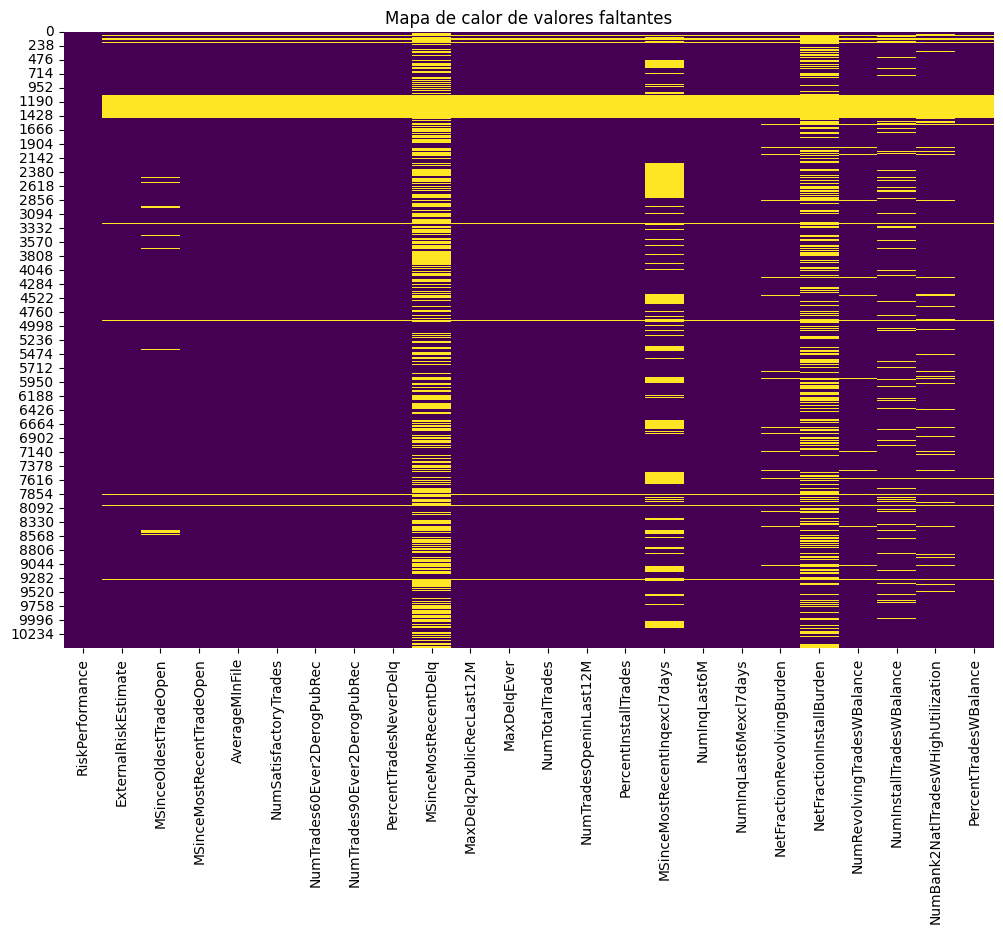

In [21]:
# Mapa de calor de los valores faltantes
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores faltantes')

Umbral para eliminar filas: 12.0 valores faltantes


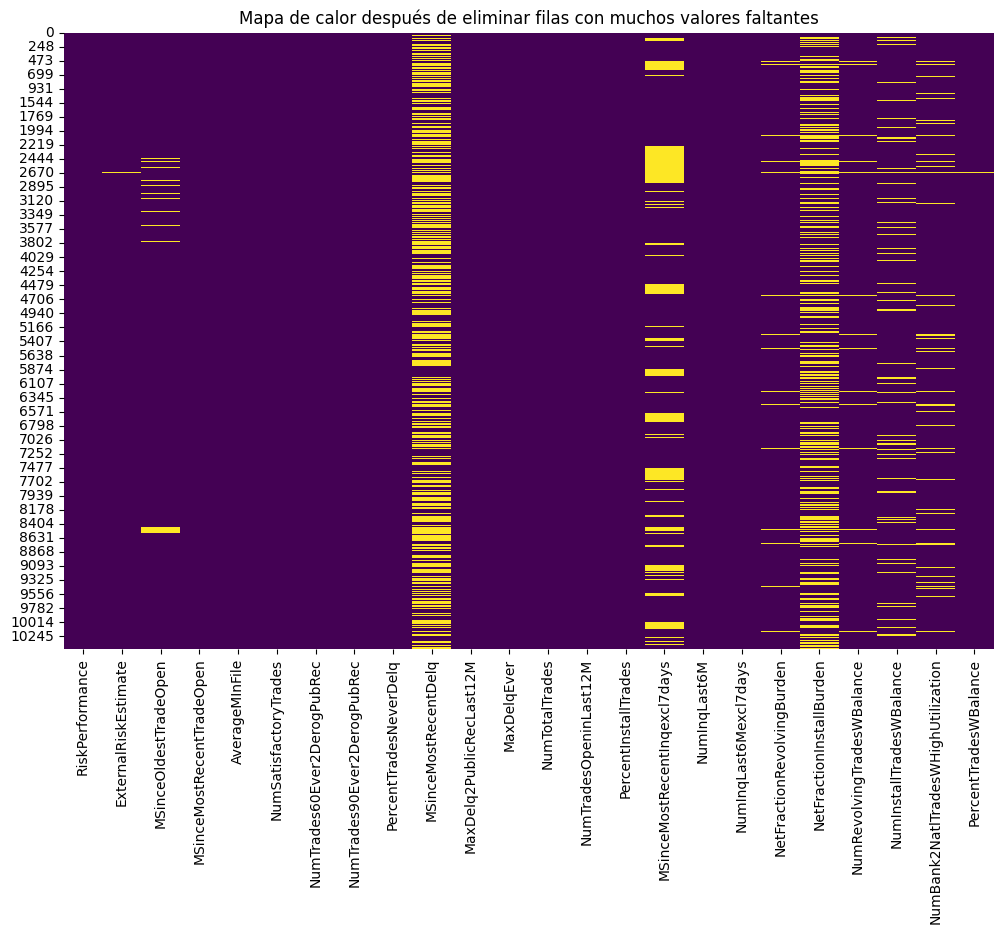

In [22]:
# Eliminar filas con más del 50% de valores faltantes
threshold = len(df.columns) * 0.5
print(f"Umbral para eliminar filas: {threshold} valores faltantes")
df = df[df.isnull().sum(axis=1) < threshold]

# Verificar el nuevo mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor después de eliminar filas con muchos valores faltantes')
plt.show()


In [23]:
df.shape

(9871, 24)

In [24]:
# Calcular el porcentaje de valores faltantes por columna y ordenar de mayor a menor
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print("Porcentaje de valores faltantes por columna:")
print(missing_percent)



Porcentaje de valores faltantes por columna:
MSinceMostRecentDelq                  49.032520
NetFractionInstallBurden              34.636815
MSinceMostRecentInqexcl7days          23.614629
NumInstallTradesWBalance               8.722521
NumBank2NatlTradesWHighUtilization     5.906190
MSinceOldestTradeOpen                  2.421234
NetFractionRevolvingBurden             1.884308
NumRevolvingTradesWBalance             1.580387
PercentTradesWBalance                  0.182352
ExternalRiskEstimate                   0.101307
NumTrades90Ever2DerogPubRec            0.000000
NumTrades60Ever2DerogPubRec            0.000000
MSinceMostRecentTradeOpen              0.000000
RiskPerformance                        0.000000
NumSatisfactoryTrades                  0.000000
AverageMInFile                         0.000000
PercentInstallTrades                   0.000000
NumTradesOpeninLast12M                 0.000000
NumTotalTrades                         0.000000
MaxDelqEver                            0.00

Columnas después de eliminar las especificadas:
Index(['RiskPerformance', 'ExternalRiskEstimate', 'MSinceOldestTradeOpen',
       'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades',
       'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec',
       'PercentTradesNeverDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver',
       'NumTotalTrades', 'NumTradesOpeninLast12M', 'PercentInstallTrades',
       'NumInqLast6M', 'NumInqLast6Mexcl7days', 'NetFractionRevolvingBurden',
       'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance',
       'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance'],
      dtype='str')


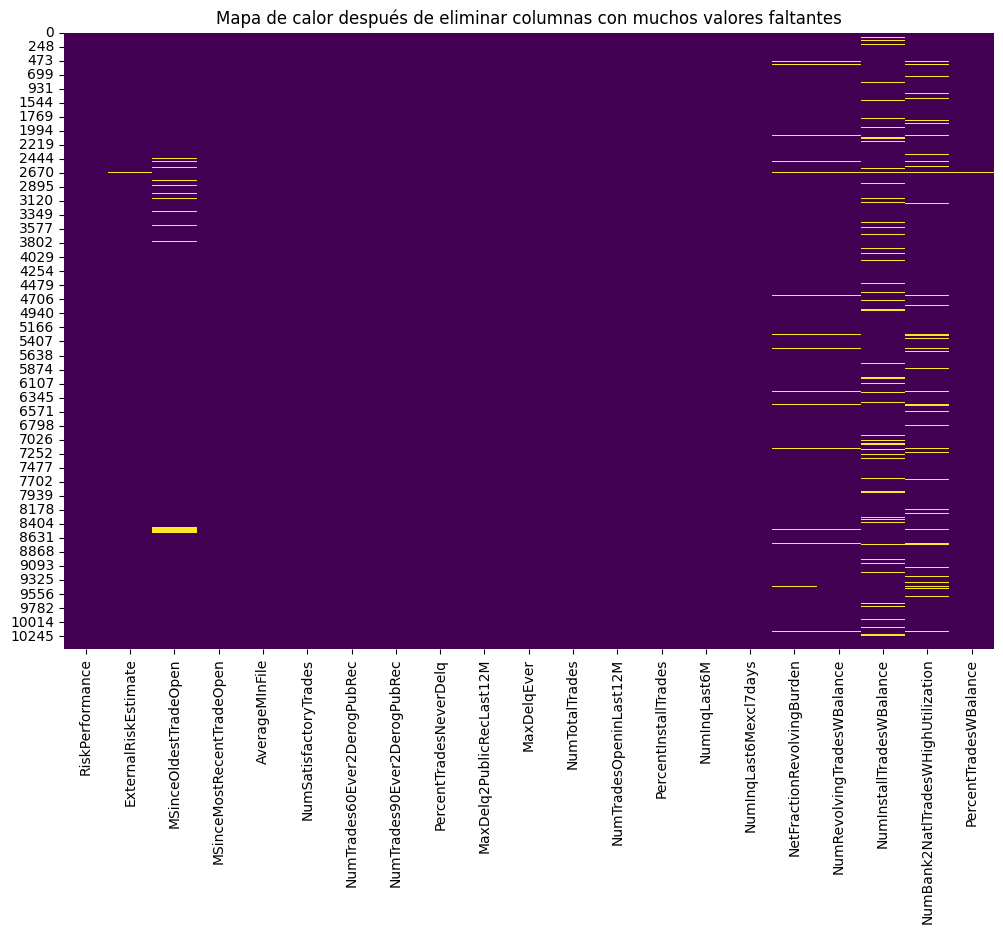

In [25]:
# Eliminar columnas MSinceMostRecentDelq, NetFractionInstallBurden y MSinceMostRecentInqexcl7days
columns_to_drop = ['MSinceMostRecentDelq', 'NetFractionInstallBurden', 'MSinceMostRecentInqexcl7days']
df.drop(columns=columns_to_drop, inplace=True)
# Verificar que las columnas se hayan eliminado
print("Columnas después de eliminar las especificadas:")
print(df.columns)

# Mapa de calor después de eliminar columnas
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor después de eliminar columnas con muchos valores faltantes')
plt.show()




# Pasos a seguir:

1. Imputar los datos faltantes con mediana y media (Usar al menos una vez).
2. Identificar datos atípicos en al menos 3 variables. Aplicar filtro por IQR o z-score.
3. Realizar un análisis exploratorio de los datos para la variable target (Riskperformance), involucrando: `ExternalRiskEstimate`, `MSinceMostRecentDelq`, `NumTotalTrades`, `PercentTradesNeverDelq`, `NetFractionRevolvingBurden`
4. Cambiar de escala al menos dos variables (minmaxScaler y standarScaler). 